<a href="https://colab.research.google.com/github/ob3x/Learn-Ds/blob/main/PenguinSexClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#1.1 Import bibliotek

In [182]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

sns.set(font_scale=1.3)
np.random.seed(42)
np.set_printoptions(precision=6, suppress=True)
sklearn.__version__

'1.6.1'

##1.2 Import danych


In [183]:
import kagglehub

path = kagglehub.dataset_download("amulyas/penguin-size-dataset")

raw_data = pd.read_csv(f"{path}/penguins_size.csv")
df = raw_data.copy()
df.info()

Using Colab cache for faster access to the 'penguin-size-dataset' dataset.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


###1.3 Zamiana typu danych object na category

In [184]:
object_cols = ["species", "island", "sex"]

for col in object_cols:
  df[col] = df[col].astype("category")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   species            344 non-null    category
 1   island             344 non-null    category
 2   culmen_length_mm   342 non-null    float64 
 3   culmen_depth_mm    342 non-null    float64 
 4   flipper_length_mm  342 non-null    float64 
 5   body_mass_g        342 non-null    float64 
 6   sex                334 non-null    category
dtypes: category(3), float64(4)
memory usage: 12.3 KB


#2.1 Sprawdzanie braków danych

In [185]:
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,10


##2.2 Usuwanie wierszy z brakiem danych w zmiennej docelowej

In [186]:
df.dropna(subset=["sex"], inplace=True)
df.isnull().sum()

,0
species,0
island,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


###2.3 Usuwanie wiersza z wadliwą zmienną docelową

In [187]:
df = df[df["sex"] != "."]
df["sex"].value_counts()

,count
sex,
MALE,168
FEMALE,165
.,0


#3.1 Wizualizacja danych, widzimy tutaj jak długość płetwy rośnie wraz z wagą

In [188]:
fig = px.scatter(df, x="flipper_length_mm", y="body_mass_g", color="sex", width=950, height=500, title="Długość płetwy vs waga", labels={"flipper_length_mm": "Długość płetwy", "body_mass_g": "Waga"})
fig.update_traces(marker_size=10)
fig.show()

In [189]:
df.head()

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,MALE


#4.1 Oddzielenie zmiennych opisujących od zmiennej docelowej

In [190]:
data = df.drop(labels=["sex"], axis=1)
target = df.pop("sex")

##4.2 Podział danych na testowe oraz treningowe

In [191]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (266, 6)
y_train shape: (266,)
X_test shape: (67, 6)
y_test shape: (67,)


#5.1 Kodowanie zmiennej docelowej

In [192]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

print(len(y_train))
print(len(y_test))

266
67


##5.2 Kodowanie zmiennych kategorycznych

In [193]:
X_train = pd.get_dummies(X_train, dtype=int, drop_first=True)
X_test = pd.get_dummies(X_test, dtype=int, drop_first=True)

print(X_train.shape)
print(X_test.shape)

(266, 8)
(67, 8)


###5.3 Standaryzacja danych

In [194]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(len(X_train))
print(len(X_test))

266
67


#6.1 Model regresji logistycznej

In [195]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(C=1, max_iter=500, solver="saga", penalty="l1", random_state=42)
log_reg.fit(X_train, y_train)

LogisticRegression(C=1, max_iter=500, penalty='l1', random_state=42,
                   solver='saga')

##6.2 Ocena modelu regresji logistycznej

Accuracy score for train data : 0.9323

Accuracy score for test data : 0.9104

              precision    recall  f1-score   support

           0       0.92      0.92      0.92        37
           1       0.90      0.90      0.90        30

    accuracy                           0.91        67
   macro avg       0.91      0.91      0.91        67
weighted avg       0.91      0.91      0.91        67



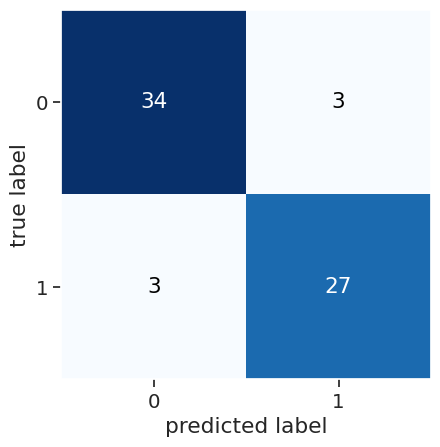

In [196]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from mlxtend.plotting import plot_confusion_matrix
from sklearn.model_selection import GridSearchCV

y_pred = log_reg.predict(X_test)
y_pred_train = log_reg.predict(X_train)

print(f"Accuracy score for train data : {accuracy_score(y_train, y_pred_train):.4f}\n")
print(f"Accuracy score for test data : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))
plot_confusion_matrix(confusion_matrix(y_test, y_pred))
plt.show()

###6.3 Znajdowanie najlepszych hiperparametrów dla regresji logistycznej

In [197]:
params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear", "saga"],
    "max_iter": [500, 1000, 2000]
}

grid_search = GridSearchCV(log_reg, param_grid=params, cv=5)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(C=1, max_iter=500, penalty='l1',
                                          random_state=42, solver='saga'),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'max_iter': [500, 1000, 2000], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear', 'saga']})

In [198]:
grid_search.best_params_

{'C': 1, 'max_iter': 500, 'penalty': 'l1', 'solver': 'liblinear'}

#7.1 Model k najbliższych sąsiadów

In [199]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

##7.2 Ocena modelu knn

Accuracy score for train data : 0.9436

Accuracy score for test data : 0.8955

              precision    recall  f1-score   support

           0       0.94      0.86      0.90        37
           1       0.85      0.93      0.89        30

    accuracy                           0.90        67
   macro avg       0.89      0.90      0.90        67
weighted avg       0.90      0.90      0.90        67



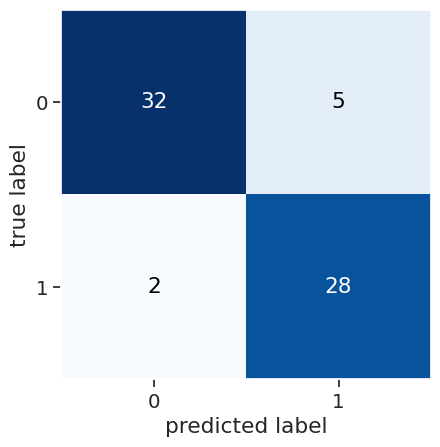

In [200]:
y_pred = knn.predict(X_test)
y_pred_train = knn.predict(X_train)

print(f"Accuracy score for train data : {accuracy_score(y_train, y_pred_train):.4f}\n")
print(f"Accuracy score for test data : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))
plot_confusion_matrix(confusion_matrix(y_test, y_pred))
plt.show()

#8.1 Model lasu losowego

In [201]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=50, max_depth=5, min_samples_leaf=5)
forest.fit(X_train, y_train)

RandomForestClassifier(max_depth=5, min_samples_leaf=5, n_estimators=50)

##8.2 Ocena modelu lasu losowego

Accuracy score for train data : 0.9624

Accuracy score for test data : 0.8507

              precision    recall  f1-score   support

           0       0.91      0.81      0.86        37
           1       0.79      0.90      0.84        30

    accuracy                           0.85        67
   macro avg       0.85      0.86      0.85        67
weighted avg       0.86      0.85      0.85        67



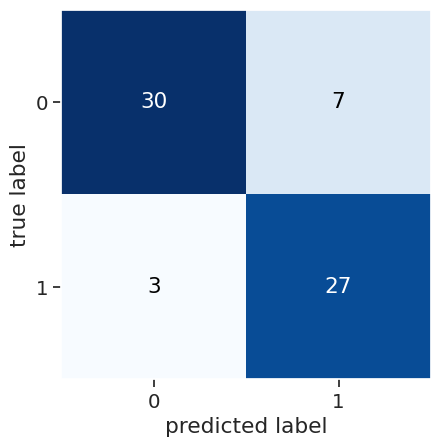

In [202]:
y_pred = forest.predict(X_test)
y_pred_train = forest.predict(X_train)

print(f"Accuracy score for train data : {accuracy_score(y_train, y_pred_train):.4f}\n")
print(f"Accuracy score for test data : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))
plot_confusion_matrix(confusion_matrix(y_test, y_pred))
plt.show()

#9.1 Maszyna wektorów nośnych

In [203]:
from sklearn.svm import SVC

svc = SVC(kernel="linear", C=1)
svc.fit(X_train, y_train)

SVC(C=1, kernel='linear')

##9.2 Ocena modelu

Accuracy score for train data : 0.9286

Accuracy score for test data : 0.9104

              precision    recall  f1-score   support

           0       0.94      0.89      0.92        37
           1       0.88      0.93      0.90        30

    accuracy                           0.91        67
   macro avg       0.91      0.91      0.91        67
weighted avg       0.91      0.91      0.91        67



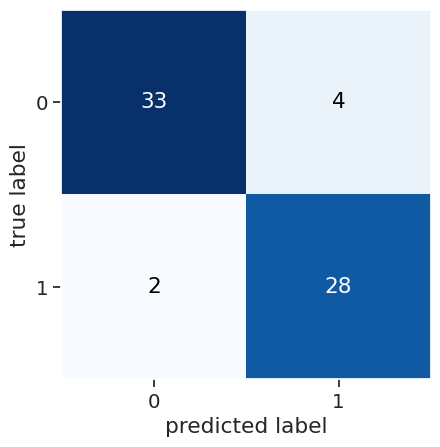

In [204]:
y_pred = svc.predict(X_test)
y_pred_train = svc.predict(X_train)

print(f"Accuracy score for train data : {accuracy_score(y_train, y_pred_train):.4f}\n")
print(f"Accuracy score for test data : {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred))
plot_confusion_matrix(confusion_matrix(y_test, y_pred))
plt.show()

###9.3 Znajdywanie najlepszych hiperparametrów dla maszyny wektorów nośnych

In [205]:
params = {
    "C": [0.01, 0.1, 1, 10, 100],
    "kernel": ["linear", "poly", "rbf", "sigmoid"]
}

grid_search = GridSearchCV(svc, param_grid=params, cv=5, scoring="accuracy")
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=SVC(C=1, kernel='linear'),
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'kernel': ['linear', 'poly', 'rbf', 'sigmoid']},
             scoring='accuracy')

In [206]:
grid_search.best_params_

{'C': 1, 'kernel': 'linear'}

#10 Wnioski

Najlepszy okazał się model maszyny wektorów nośnych, który dał nam accuracy score na poziomie 0.9104 dla danych testowych, taki sam wynik uzyskała regresja logistyczna. Maszyna wektorów nośnych miała mniejszą różnicę między danymi testowymi oraz treningowymi co ograniczy nam przeuczenie.